## Description
Main python script used to assess climate characteristics and adaptation measures in Pisor, Touma et al. (in prep)<br>
Sricpts by [Danielle Touma](danielletouma.com)<br>
Run script in Jupyter Notebook or platform with *.ipynb capabilities.

### External functions
[find_runs.py](https://gist.github.com/alimanfoo/c5977e87111abe8127453b21204c1065)

## Main script

### Import packages/libraries

In [1]:
# analysis packages
import numpy as np
import pandas as pd
from scipy.ndimage import label, binary_dilation, generate_binary_structure
from find_runs import * # function found in find_runs.py
import xarray as xr
import xesmf as xe
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from statsmodels.tsa.stattools import acf
import cartopy.crs as ccrs
import cartopy.feature as cfeature

### Basic set up

Initialize directories where you can find the precipitation dataset (dir_month),
the threshold dataset (dir_pxx), shapefile (dir_shp), and remittance data (dir_rem), and
where figures should be output (dir_fig).

In [2]:
dir_spei = "/disk/dtouma/CEDA/"
dir_ndvi = "/disk/dtouma/NDVI/Africa/monthly_average/"
dir_fig = "/disk/dtouma/figures/"
dir_shp =  "/disk/dtouma/shapefiles/"
dir_rem = "/disk/dtouma/remittance/"
dir_out = "/disk/dtouma/remittance/GCB_paper_csvs/"
dir_regions = "/disk/dtouma/remittance/country_csvs/"
dir_lights =  '/disk/dtouma/nightlights/'

In [3]:
period_year0 = [1995, 2000, 2005] #start year of period
period_year1 = [2009, 2009, 2009] #end year of period
nperiods = len(period_year0) # number of periods

### Read in SPEI files

We use CHIRPS-hPET SPEI Data.

More info:

Website for download: https://catalogue.ceda.ac.uk/uuid/ac43da11867243a1bb414e1637802dec
paper: https://essd.copernicus.org/articles/15/5449/2023/

Available datasets: 
SPEI from 1 to 48 months. 1981-2022. Global.

Precipitation datasets:
- CHIRPS (0.05 degrees)
- MSWEP (0.25 degrees)
- CRU-TS (0.5 degrees)

PET datasts:
- GLEAM (Priestley–Taylor equation; satellite & reanalysis data; 0.25 degrees)
- hPET (Penman Monteith equation; ERA5-Land reanalysis; 0.1 degrees)
- CRU-TS (Penman Monteith equation; CRU-TS; 0.5 degrees)

SPEI datasets:
CHIRPS_GLEAM, CHIRPS_hPET, MSWEP_GLEAM, MSWEP_hPET. All are statistically interpolated to 0.05 degrees.

**We use the CHIRPS_GLEAM dataset at 0.05 resolution, already subset for Africa, for 1-, 3-, 6- and 12-month SPEI.**

In [4]:
# Reading subsetted Africa SPEI for different time scales:
# 1-, 3-, 6- and 12-month SPEI.
# This will allow us to better understand different timescales of drought

spei_time_scales = [3, 12] #[1, 3, 6, 12]
spei_file_list = []
for tt in spei_time_scales:
    spei_file_list.append(dir_spei+'Africa_spei'+"%02d" % (tt,)+'.nc')

spei_all_xr = xr.open_mfdataset(spei_file_list, combine='nested' ,concat_dim='time_scale')

In [5]:
# subsetting for time period until survey year since that is what people feel "climatologically"
survey_year = 2009
spei_all_years = spei_all_xr.time.dt.year
year0 = int(spei_all_years[0])
spei_sub_xr = spei_all_xr.sel(time=spei_all_xr.time.dt.year.isin(np.arange(year0,survey_year+1,1)))

# convert xarray into numpy array
spei_sub_np = np.array(spei_sub_xr.spei)

/home/staff/dtouma/miniconda3/envs/climenv/lib/python3.12/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]


Initialize variables that describe the dimensions of your SPEI dataset.

In [6]:
time_xr = spei_sub_xr.time
lon_xr = spei_sub_xr.lon 
lat_xr = spei_sub_xr.lat 

nlat = len(lat_xr)
nlon = len(lon_xr)
ntime = len(time_xr)

lon = np.array(lon_xr)
lat = np.array(lat_xr)

Calculate grid area for dataset

In [7]:
lat_sep = lat[1]-lat[0]
lon_sep = lon[1]-lon[0]

def gridsize(lat1, lon1, lat2, lon2):
   #https://en.wikipedia.org/wiki/Haversine_formula
   #https://stackoverflow.com/questions/639695/how-to-convert-latitude-or-longitude-to-meters/11172685#11172685
   R = 6378.137 # // Radius of earth in km
   dLat = lat2 * np.pi / 180 - lat1 * np.pi / 180
   dLon = lon2 * np.pi / 180 - lon1 * np.pi / 180
   a = np.sin(dLat/2) * np.sin(dLat/2) + np.cos(lat1 * np.pi / 180) * np.cos(lat2 * np.pi / 180) * np.sin(dLon/2) * np.sin(dLon/2)
   c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
   d = R * c
   return d * 1000 #; // meters

grid_area = np.zeros(shape=(nlat,nlon))

for ii in range(0,nlat,1):
   for jj in range(0,nlon,1):
      grid_area[ii,jj] = gridsize((lat[ii]-(lat_sep/2)),(lon[jj]-(lon_sep/2)),
                                  (lat[ii]+(lat_sep/2)),(lon[jj]+(lon_sep/2)))

### Read in NDVI monthly average file<br>
NDVI monthly data for Africa has been processed from global daily files (subset spatially and temporally averaged). <br>
Original netCDF files are downloaded from NOAA Climate Data Record (CDR) of AVHRR Normalized Difference Vegetation Index (NDVI), Version 5 (https://www.ncei.noaa.gov/metadata/geoportal/rest/metadata/item/gov.noaa.ncdc:C01558/html). <br> Processing was done in CDO - a command line language that can be used to process netCDF files. <br> The average monthly file that was used in this study can be found on the Zenodo for the paper: [Zenodo link].

In [8]:
year0_ndvi = 1982
year1_ndvi = 2009

ndvi_xr = xr.open_dataset(dir_ndvi+'AVHRR-Land_v005_AVH13C1_NOAA_'+str(year0_ndvi)+'-'+str(year1_ndvi)+'_monthly_average_Africa.nc')    

/home/staff/dtouma/miniconda3/envs/climenv/lib/python3.12/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


Calculate annual mean NDVI

In [9]:
ndvi_annual_mean = ndvi_xr.NDVI.groupby('time.year').mean('time')

Calculate SVI (Standardized vegetation index)<br>
$SVI = (NDVI_{t,i,j} - \mu_{i,j})/ \sigma_{i,j}$<br>
The SVI reflects if the vegetation is relatively healthy (>0; wet conditions) or relatively unhealthy (<0; drought conditions).

In [10]:
# find monthly mean and standard deviation across all dataset
ndvi_mu_month = ndvi_xr.NDVI.groupby('time.month').mean('time')
ndvi_sig_month = ndvi_xr.NDVI.groupby('time.month').std('time')
# standardize using (NDVI - mu)/sigma
SVI = (ndvi_xr.NDVI - ndvi_mu_month.sel(month=ndvi_xr.NDVI.time.dt.month))/ndvi_sig_month.sel(month=ndvi_xr.NDVI.time.dt.month)

### Regrid SVI and NDVI to SPEI grid

Build regridder

In [11]:
ds_out = xr.Dataset(
    {
        "lat": spei_sub_xr.lat,
        "lon": spei_sub_xr.lon,
    }
)

regridder = xe.Regridder(SVI, ds_out, "bilinear")


regrid SVI, NDVI, and NDVI annual mean using regridder

In [12]:
SVI_regridded = regridder(SVI)
NDVI_regridded = regridder(ndvi_xr.NDVI)
NDVI_annual_mean_regridded = regridder(ndvi_annual_mean)

In [13]:
SVI_regridded_np = np.array(SVI_regridded)
NDVI_regridded_np = np.array(NDVI_regridded)
NDVI_annual_regridded_np = np.array(NDVI_annual_mean_regridded) 

Pad the arrays so that the time dimension is the same as the SPEI array. In this case, the NDVI data starts one year after the SPEI, so we have a whole year of missing SVI values in 1981. 

In [14]:
SVI_regridded_np_padded = np.pad(SVI_regridded_np, [(12, 0), (0, 0), (0, 0)], mode='constant', constant_values=-999999)
SVI_regridded_np_padded = np.ma.masked_where(SVI_regridded_np_padded==-999999, SVI_regridded_np_padded)
NDVI_regridded_np_padded = np.pad(NDVI_regridded_np, [(12, 0), (0, 0), (0, 0)], mode='constant', constant_values=-999999)
NDVI_regridded_np_padded = np.ma.masked_where(NDVI_regridded_np_padded==-999999, NDVI_regridded_np_padded)
NDVI_annual_regridded_np_padded = np.pad(NDVI_annual_regridded_np, [(12, 0), (0, 0), (0, 0)], mode='constant', constant_values=-999999)
NDVI_annual_regridded_np_padded = np.ma.masked_where(NDVI_annual_regridded_np_padded==-999999, NDVI_annual_regridded_np_padded)

In [15]:
period_NDVI_mean = np.full(fill_value=-999.0,shape=(nperiods,nlat,nlon))
for pp in range(0,nperiods,1):
    print('period = '+str(pp))
    period_year_inds = np.where((time_xr.dt.year>=period_year0[pp])&(time_xr.dt.year<=period_year1[pp]))[0]
    period_NDVI_mean[pp,:,:] = np.ma.mean(NDVI_regridded_np_padded[period_year_inds,:,:], axis=0)

period = 0
period = 1
period = 2


#### Finding droughts and calculating frequency, DIMS, and spatial extent.

Create a binary variable storing whether or not a pixel is below a certain drought threshold (1 = drought, 0 = no drought) for several percentile thresholds.
First calculate percentile threshold values and then find the locations and times when the spei value is equal to or less than the percentile threshold.

In [17]:
# calculate percentile threshold values
percentile = 10 #percentiles = np.array([2, 5, 10, 20, 50]) # severe drought to moderately dry conditions
spei_percentiles = np.zeros((len(spei_time_scales),nlat,nlon))
for tt in range(0,len(spei_time_scales),1):
    print(str(spei_time_scales[tt])+'-month SPEI')
    spei_percentiles[tt,:,:] = np.nanpercentile(spei_sub_np[tt,:,:,:], percentile, axis=0) #spei percentiles has the thresholds for each time scale and grid point (timescale x lat x lon)
    # need nanpercentile since end values are nan for >1-month running average for SPEI


3-month SPEI


/home/staff/dtouma/miniconda3/envs/climenv/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


12-month SPEI


Create SPEI binary dataset based on percentiles

In [18]:
spei_binary_perc = np.zeros((len(spei_time_scales),
                        ntime,
                        nlat,
                        nlon,),
                        dtype=int)

for mm in range(0,ntime,1):
    if (mm%12==0):
        print(str(mm+1)+' out of '+ str(ntime))
    percentile_inds = np.where(spei_sub_np[:,mm,:,:]<=spei_percentiles)
    spei_binary_perc[percentile_inds[0],mm,percentile_inds[1],percentile_inds[2]] = 1 


1 out of 348
13 out of 348
25 out of 348
37 out of 348
49 out of 348
61 out of 348
73 out of 348
85 out of 348
97 out of 348
109 out of 348
121 out of 348
133 out of 348
145 out of 348
157 out of 348
169 out of 348
181 out of 348
193 out of 348
205 out of 348
217 out of 348
229 out of 348
241 out of 348
253 out of 348
265 out of 348
277 out of 348
289 out of 348
301 out of 348
313 out of 348
325 out of 348
337 out of 348


Find one or more consecutive months with drought. drought_onsets = 1 when a drought starts over each grid point. drought_lengths = corresponding drought duration of that drought onset

New frequency calculation

In [19]:
period_timescale_ann_freq = np.zeros((len(spei_time_scales),nperiods,nlat,nlon))
for pp in range(0,nperiods,1):
    print('period = '+str(pp))
    period_year_inds = np.where((time_xr.dt.year>=period_year0[pp])&(time_xr.dt.year<=period_year1[pp]))[0]
    period_timescale_ann_freq[:,pp,:,:] = np.sum(spei_binary_perc[:,period_year_inds,:,:], axis=1)/(period_year1[pp]-period_year0[pp]+1)

period = 0
period = 1
period = 2


Calculate ACF for each period and spei time scale

In [20]:

period_timescale_ACF = np.zeros((len(spei_time_scales),nperiods,nlat,nlon))
for pp in range(0,nperiods,1):
    print('period = '+str(pp))
    period_year_inds = np.where((time_xr.dt.year>=period_year0[pp])&(time_xr.dt.year<=period_year1[pp]))[0]
    for ii in range(0,nlat,1):
        if ii%50==0:
            print('lat = '+str(ii))
        for jj in range(0,nlon,1): 
            for tt in range(0,len(spei_time_scales),1):
                period_timescale_ACF[tt,pp,ii,jj] = acf(spei_binary_perc[tt,period_year_inds,ii,jj] , nlags = spei_time_scales[tt])[spei_time_scales[tt]]


period = 0
lat = 0


/home/staff/dtouma/miniconda3/envs/climenv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


lat = 50
lat = 100
lat = 150
lat = 200
lat = 250
lat = 300
lat = 350
lat = 400
lat = 450
lat = 500
lat = 550
lat = 600
lat = 650
lat = 700
lat = 750
lat = 800
lat = 850
lat = 900
lat = 950
lat = 1000
lat = 1050
lat = 1100
lat = 1150
lat = 1200
lat = 1250
lat = 1300
lat = 1350
lat = 1400
period = 1
lat = 0
lat = 50
lat = 100
lat = 150
lat = 200
lat = 250
lat = 300
lat = 350
lat = 400
lat = 450
lat = 500
lat = 550
lat = 600
lat = 650
lat = 700
lat = 750
lat = 800
lat = 850
lat = 900
lat = 950
lat = 1000
lat = 1050
lat = 1100
lat = 1150
lat = 1200
lat = 1250
lat = 1300
lat = 1350
lat = 1400
period = 2
lat = 0
lat = 50
lat = 100
lat = 150
lat = 200
lat = 250
lat = 300
lat = 350
lat = 400
lat = 450
lat = 500
lat = 550
lat = 600
lat = 650
lat = 700
lat = 750
lat = 800
lat = 850
lat = 900
lat = 950
lat = 1000
lat = 1050
lat = 1100
lat = 1150
lat = 1200
lat = 1250
lat = 1300
lat = 1350
lat = 1400


For each period, find the total *departure* of all drought months (*i<sub>1</sub>* and *i<sub>2</sub>* in Figure 1).

In [38]:
period_timescale_severity= np.full(fill_value = 999.0, shape=(len(spei_time_scales),nperiods, nlat, nlon) ,dtype=float) 

spei_departure = spei_sub_np - spei_percentiles[:,np.newaxis,:,:]

drought_departure = np.ma.masked_array(spei_departure,mask=((np.isnan(spei_departure))|(spei_binary_perc==0)))
# drought_departure = spei_departure * spei_binary_perc

for pp in range(0,nperiods,1):
    print('period = '+str(pp))
    period_year_inds = np.where((time_xr.dt.year>=period_year0[pp])&(time_xr.dt.year<=period_year1[pp]))[0]
    period_timescale_severity[:,pp,:,:] = np.ma.mean(drought_departure[:,period_year_inds,:,:], axis=1)



period = 0
period = 1
period = 2


Find SVI severity for each timescale and period - mean over all drought months 

In [22]:
period_timescale_SVI= np.full(fill_value = 999.0, shape=(len(spei_time_scales),nperiods, nlat, nlon) ,dtype=float) 

SVI_4d = np.broadcast_to(SVI_regridded_np_padded,spei_binary_perc.shape) 

drought_SVI = np.ma.masked_array(SVI_4d,mask=(spei_binary_perc==0))

# drought_SVI = SVI_regridded_np_padded[np.newaxis,:,:,:] * spei_binary_perc

for pp in range(0,nperiods,1):
    print('period = '+str(pp))
    period_year_inds = np.where((time_xr.dt.year>=period_year0[pp])&(time_xr.dt.year<=period_year1[pp]))[0]
    period_timescale_SVI[:,pp,:,:] = np.ma.mean(drought_SVI[:,period_year_inds,:,:], axis=1)


period = 0
period = 1
period = 2


In [23]:
# Finding spatially connected droughts, or 'drought objects', object area, their total and mean intensity across the object.
# These objects are not connected in time, instead, each month has their own set of objects.

spei_perc_object_ngrids = np.zeros(shape=(len(spei_time_scales),ntime,nlat,nlon), dtype='int')
spei_perc_object_area_m2 = np.zeros(shape=(len(spei_time_scales),ntime,nlat,nlon)) 
spei_perc_nobjects = np.zeros((len(spei_time_scales),ntime), dtype='int')

# user defined structures for finding connected objects
l_structure = [[1,1,1],[1,1,1],[1,1,1]] # structure for finding connected areas - this structure allows edges and vertices to be connected (queen's case) 

for tt in range(0,len(spei_time_scales),1):
     print(str(spei_time_scales[tt])+'-month SPEI')
     for mm in range(0,ntime,1):
          mm_binary = spei_binary_perc[tt,mm,:,:]
          mm_labels, mm_nlabels = label(mm_binary, structure=l_structure)
          spei_perc_nobjects[tt,mm] = mm_nlabels
          print(str(mm)+' out of '+str(ntime)+' months: '+str(mm_nlabels))
          for obj in range(0,mm_nlabels,1):
               obj_inds = np.where(mm_labels==(obj+1))
               spei_perc_object_ngrids[tt,mm,obj_inds[0],obj_inds[1]] = len(obj_inds[0])
               spei_perc_object_area_m2[tt,mm,obj_inds[0],obj_inds[1]] = np.sum(grid_area[obj_inds[0],obj_inds[1]])

3-month SPEI
0 out of 348 months: 0
1 out of 348 months: 0
2 out of 348 months: 57
3 out of 348 months: 80
4 out of 348 months: 117
5 out of 348 months: 168
6 out of 348 months: 159
7 out of 348 months: 119
8 out of 348 months: 132
9 out of 348 months: 228
10 out of 348 months: 296
11 out of 348 months: 365
12 out of 348 months: 332
13 out of 348 months: 141
14 out of 348 months: 186
15 out of 348 months: 207
16 out of 348 months: 186
17 out of 348 months: 104
18 out of 348 months: 233
19 out of 348 months: 478
20 out of 348 months: 517
21 out of 348 months: 279
22 out of 348 months: 250
23 out of 348 months: 249
24 out of 348 months: 303
25 out of 348 months: 473
26 out of 348 months: 624
27 out of 348 months: 742
28 out of 348 months: 860
29 out of 348 months: 538
30 out of 348 months: 457
31 out of 348 months: 466
32 out of 348 months: 594
33 out of 348 months: 520
34 out of 348 months: 577
35 out of 348 months: 371
36 out of 348 months: 307
37 out of 348 months: 535
38 out of 348 m

In [24]:
# period_timescale_max_area_drought_event = np.full(fill_value = -999.0, shape=(len(spei_time_scales),nperiods, nlat, nlon) ,dtype=float)
period_timescale_avg_area = np.full(fill_value = -999.0, shape=(len(spei_time_scales),nperiods, nlat, nlon) ,dtype=float)

# drought_area = spei_perc_object_area_m2 * spei_binary_perc
drought_area_masked = np.ma.masked_array(spei_perc_object_area_m2,mask=(spei_binary_perc==0))

for pp in range(0,nperiods,1):
    print('period = '+str(pp))
    period_year_inds = np.where((time_xr.dt.year>=period_year0[pp])&(time_xr.dt.year<=period_year1[pp]))[0]
    period_timescale_avg_area[:,pp,:,:] = np.ma.mean(drought_area_masked[:,period_year_inds,:,:], axis=1)
     

period = 0
period = 1
period = 2


### Calculate frequency, DIMS, dispersion, SVI severity, and area for selected periods. 

### Nighttime Lights City Centers

Find closest population centers using processed night time lights. nighttime_lights.csv can be found in the GitHub.

In [25]:
lights_df = pd.read_csv(dir_lights+'nighttime_lights.csv')

In [26]:
# This function allows us to find the closest city center location - will be used in loop at the end.
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return array[idx]

In [143]:
precision = 2
base = 0.05

# create SPEI data frame
lat_2d = np.repeat(np.around(lat, decimals=2),len(lon))
lon_2d = np.tile(np.around(lon, decimals=2),len(lat))

#select period
rr='south africa'
pp=2
tt=0
spei_df = pd.DataFrame({
    'lat_SPEI':lat_2d,'long_SPEI':lon_2d,
    'annual_frequency': period_timescale_ann_freq[tt,pp,:,:].flat,
    'severity': period_timescale_severity[tt,pp,:,:].flat,
    'autocorrelation': period_timescale_ACF[tt,pp,:,:].flat,
    'avg_area': period_timescale_avg_area[tt,pp,:,:].flat,
    'NDVI_mean': period_NDVI_mean[pp,:,:].flat,
    'SVI_severity': period_timescale_SVI[tt,pp,:,:].flat,
    })
        
remit_df = pd.read_csv(dir_regions+rr+'.csv', encoding = "ISO-8859-1")
existing_columns = list(set(remit_df.columns) & set(spei_df.columns))
remit_df = remit_df.drop(columns=existing_columns)
if 'lat_regrid' in remit_df.columns:
    remit_df = remit_df.drop(columns=['lat_regrid','long_regrid'])
remit_lat = np.array(remit_df['lat'])
remit_lat_rounded = np.round(base*np.round(remit_lat/base), decimals=precision)
remit_lon = np.array(remit_df['long'])
remit_lon_rounded = np.round(base*np.round(remit_lon/base), decimals=precision)

remit_df['lat_SPEI'] = remit_lat_rounded
remit_df['long_SPEI'] = remit_lon_rounded
remit_df['NDVI_lat'] = remit_df['lat_SPEI']
remit_df['NDVI_lon'] = remit_df['long_SPEI']
#city centers (nighttime lights)
region_lights_df = lights_df[lights_df['NAME_0']==rr.title()].reset_index(drop=True)
lights_lat = region_lights_df['latitude']
lights_lon = region_lights_df['longitude']
remit_lat_nearest = np.zeros(len(remit_lat))
for ii in range(0,len(remit_lat),1):
    remit_lat_nearest[ii] = find_nearest(lights_lat,remit_lat[ii])
remit_lon_nearest = np.zeros(len(remit_lon))
for jj in range(0,len(remit_lon),1):
    remit_lon_nearest[jj] = find_nearest(lights_lon,remit_lon[jj]) 
remit_df['pop_cent_lat'] = remit_lat_nearest
remit_df['pop_cent_long'] = remit_lon_nearest
#merge remittance dataframe with spei dataframe by matching regridded lat longs
spei_remit_df = pd.merge(remit_df,spei_df,how='left',on=['lat_SPEI','long_SPEI'])
rows_with_nan = spei_remit_df[(spei_remit_df['NDVI_mean'].isna())&~(spei_remit_df['lat'].isna())]

if len(rows_with_nan)>0:
    period_NDVI_mean_xr = xr.DataArray(period_NDVI_mean[pp,:,:],coords = {'lat' : spei_sub_xr.lat, 'lon' : spei_sub_xr.lon}, name='NDVI_period')
    print(str(len(rows_with_nan)) + ' NDVI nans')
    # first try to fix using xarray find nearest using original lat long
    for nn in rows_with_nan.index:
        NDVI_missing = period_NDVI_mean_xr.sel(lat=rows_with_nan.loc[nn]['lat'], lon = rows_with_nan.loc[nn]['long'], method='nearest')
        if np.isnan(NDVI_missing.values.item()):
        # incrementally change lat and long until non-nan value is reached
            for ii in np.arange(-30,31,1):
                ii_check = period_NDVI_mean_xr.sel(lat=rows_with_nan.loc[nn]['lat']+base*ii, lon = rows_with_nan.loc[nn]['long'], method='nearest') 
                if ~np.isnan(ii_check.values.item()):
                    spei_remit_df.at[nn,'NDVI_mean'] = ii_check.values.item()
                    spei_remit_df.at[nn,'NDVI_lat'] = ii_check.lat
                    spei_remit_df.at[nn,'NDVI_lon'] = ii_check.lon
                    break
                else:
                    jj_check = period_NDVI_mean_xr.sel(lat=rows_with_nan.loc[nn]['lat']+base*ii, lon = rows_with_nan.loc[nn]['long']+base*ii, method='nearest')
                    if ~np.isnan(jj_check.values.item()):
                        spei_remit_df.at[nn,'NDVI_mean'] = jj_check.values.item()
                        spei_remit_df.at[nn,'NDVI_lat'] = jj_check.lat
                        spei_remit_df.at[nn,'NDVI_lon'] = jj_check.lon
                        break
        else:
            spei_remit_df.at[nn,'NDVI_mean'] = NDVI_missing.values.item()
            spei_remit_df.at[nn,'NDVI_lat'] = NDVI_missing.lat
            spei_remit_df.at[nn,'NDVI_lon'] = NDVI_missing.lon  

rows_with_nan_after = spei_remit_df[(spei_remit_df['NDVI_mean'].isna())&~(spei_remit_df['lat'].isna())]
print(len(rows_with_nan_after))
print(rows_with_nan[['lat','NDVI_lat','long','NDVI_lon']])

0
Empty DataFrame
Columns: [lat, NDVI_lat, long, NDVI_lon]
Index: []


In [133]:
rows_with_nan[['lat','long','NDVI_lon']]

,lat,long,NDVI_lon
12,14.716884,-17.466839,-17.45
21,14.747950,-17.447150,-17.45
27,14.685622,-17.450347,-17.45
30,14.776832,-17.405190,-17.40
37,14.747950,-17.447150,-17.45
...,...,...,...
1948,14.776832,-17.405190,-17.40
1949,14.718070,-17.457180,-17.45
1950,14.716600,-17.462700,-17.45
1951,14.826800,-17.270160,-17.25


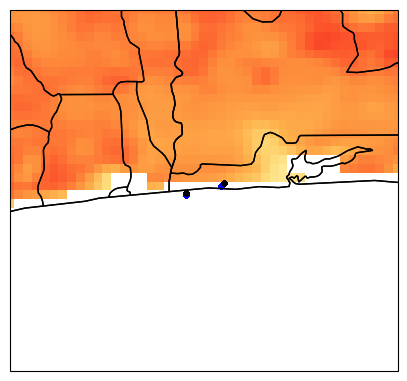

In [141]:
projection = ccrs.PlateCarree() 
fig, ax = plt.subplots(1,1,figsize=(5,5),
                      subplot_kw={'projection': projection},
                      )

# levels_ba = MaxNLocator(nbins=30).tick_values(0,1.1e9)
cmap_ba = plt.colormaps['YlOrRd'] #'YlOrBr_r', 'YlOrRd', 'YlGn', 'pink_r'
# norm_ba = BoundaryNorm(levels_ba, ncolors=cmap_ba.N, clip=True)

ax.set_extent([np.min(rows_with_nan.NDVI_lon)-1,
               np.max(rows_with_nan.NDVI_lon)+1,
               np.min(rows_with_nan.NDVI_lat)-1,
               np.max(rows_with_nan.NDVI_lat)+1],
               crs=ccrs.PlateCarree()) #PacCoast
ax.coastlines(color='black')
ax.add_feature(cfeature.BORDERS,edgecolor='black')
ax.add_feature(cfeature.STATES,edgecolor='black')
# ax.add_feature(cfeature.RIVERS,edgecolor='darkblue')
# ax.add_feature(cfeature.OCEAN,facecolor='white',zorder=9)

# plot_char, lon = add_cyclic_point(total_burn_area_subset, coord=total_burn_area_subset.lon)
cs_ba = ax.pcolormesh(lon, lat, period_NDVI_mean[pp,:,:],
                            # norm=norm_ba,
                            cmap=cmap_ba,
                            transform = ccrs.PlateCarree(),
                            )

ax.scatter(rows_with_nan.NDVI_lon,rows_with_nan.NDVI_lat,s=10,color='blue')
ax.scatter(rows_with_nan.long,rows_with_nan.lat,s=10,color='black')

# ax.scatter(rows_with_nan_after.NDVI_lon,rows_with_nan_after.NDVI_lat,s=10,color='black')


For each region and period, read in remittance data, merge with SPEI data, ensure NDVI is not NAN, find population centers, save output file.

In [39]:
regions = ['nigeria','kenya','burkina faso','south africa', 'uganda','senegal']

# for "regridding" survey lat/longs to SPEI lat/longs
precision = 2
base = 0.05

NDVI_search_radius = 30
sev_search_radius = 30

# create SPEI data frame
lat_2d = np.repeat(np.around(lat, decimals=2),len(lon))
lon_2d = np.tile(np.around(lon, decimals=2),len(lat))

#select period
for pp in range(0,nperiods,1):
    print(str(period_year0[pp])+'-'+str(period_year1[pp]))
    for tt in range(0,len(spei_time_scales),1):
        print(str(spei_time_scales[tt])+'-month SPEI')
        spei_df = pd.DataFrame({
            'lat_SPEI':lat_2d,'long_SPEI':lon_2d,
            'annual_frequency': period_timescale_ann_freq[tt,pp,:,:].flat,
            'severity': period_timescale_severity[tt,pp,:,:].flat,
            'autocorrelation': period_timescale_ACF[tt,pp,:,:].flat,
            'avg_area': period_timescale_avg_area[tt,pp,:,:].flat,
            'NDVI_mean': period_NDVI_mean[pp,:,:].flat,
            'SVI_severity': period_timescale_SVI[tt,pp,:,:].flat,
            })
        for rr in regions:
            print(rr)
            remit_df = pd.read_csv(dir_regions+rr+'.csv', encoding = "ISO-8859-1")
            existing_columns = list(set(remit_df.columns) & set(spei_df.columns))
            remit_df = remit_df.drop(columns=existing_columns)
            if 'lat_regrid' in remit_df.columns:
                remit_df = remit_df.drop(columns=['lat_regrid','long_regrid'])
            remit_lat = np.array(remit_df['lat'])
            remit_lat_rounded = np.round(base*np.round(remit_lat/base), decimals=precision)
            remit_lon = np.array(remit_df['long'])
            remit_lon_rounded = np.round(base*np.round(remit_lon/base), decimals=precision)
            remit_df['lat_SPEI'] = remit_lat_rounded
            remit_df['long_SPEI'] = remit_lon_rounded
            remit_df['NDVI_lat'] = remit_df['lat_SPEI']
            remit_df['NDVI_lon'] = remit_df['long_SPEI']
            remit_df['sev_lat'] = remit_df['lat_SPEI']
            remit_df['sev_lon'] = remit_df['long_SPEI']
            #city centers (nighttime lights)
            region_lights_df = lights_df[lights_df['NAME_0']==rr.title()].reset_index(drop=True)
            lights_lat = region_lights_df['latitude']
            lights_lon = region_lights_df['longitude']
            remit_lat_nearest = np.zeros(len(remit_lat))
            for ii in range(0,len(remit_lat),1):
                remit_lat_nearest[ii] = find_nearest(lights_lat,remit_lat[ii])
            remit_lon_nearest = np.zeros(len(remit_lon))
            for jj in range(0,len(remit_lon),1):
                remit_lon_nearest[jj] = find_nearest(lights_lon,remit_lon[jj]) 
            remit_df['pop_cent_lat'] = remit_lat_nearest
            remit_df['pop_cent_long'] = remit_lon_nearest
            #merge remittance dataframe with spei dataframe by matching regridded lat longs
            spei_remit_df = pd.merge(remit_df,spei_df,how='left',on=['lat_SPEI','long_SPEI'])
            rows_with_nan_NDVI = spei_remit_df[(spei_remit_df['NDVI_mean'].isna())&~(spei_remit_df['lat'].isna())]
            print(str(len(rows_with_nan_NDVI)) + ' NDVI nans')
            if len(rows_with_nan_NDVI)>0:
                period_NDVI_mean_xr = xr.DataArray(period_NDVI_mean[pp,:,:],coords = {'lat' : spei_sub_xr.lat, 'lon' : spei_sub_xr.lon}, name='NDVI_period')
                # first try to fix using xarray find nearest using original lat long
                for nn in rows_with_nan_NDVI.index:
                    NDVI_missing = period_NDVI_mean_xr.sel(lat=rows_with_nan_NDVI.loc[nn]['lat'], lon = rows_with_nan_NDVI.loc[nn]['long'], method='nearest')
                    if np.isnan(NDVI_missing.values.item()):
                    # incrementally change lat and long until non-nan value is reached
                        for ii in np.arange(-1*NDVI_search_radius,NDVI_search_radius+1,1):
                            ii_check = period_NDVI_mean_xr.sel(lat=rows_with_nan_NDVI.loc[nn]['lat']+base*ii, lon = rows_with_nan_NDVI.loc[nn]['long'], method='nearest') 
                            if ~np.isnan(ii_check.values.item()):
                                spei_remit_df.at[nn,'NDVI_mean'] = ii_check.values.item()
                                spei_remit_df.at[nn,'NDVI_lat'] = ii_check.lat
                                spei_remit_df.at[nn,'NDVI_lon'] = ii_check.lon
                                break
                            else:
                                jj_check = period_NDVI_mean_xr.sel(lat=rows_with_nan_NDVI.loc[nn]['lat']+base*ii, lon = rows_with_nan_NDVI.loc[nn]['long']+base*ii, method='nearest')
                                if ~np.isnan(jj_check.values.item()):
                                    spei_remit_df.at[nn,'NDVI_mean'] = jj_check.values.item()
                                    spei_remit_df.at[nn,'NDVI_lat'] = jj_check.lat
                                    spei_remit_df.at[nn,'NDVI_lon'] = jj_check.lon
                                    break
                    else:
                        spei_remit_df.at[nn,'NDVI_mean'] = NDVI_missing.values.item()
                        spei_remit_df.at[nn,'NDVI_lat'] = NDVI_missing.lat
                        spei_remit_df.at[nn,'NDVI_lon'] = NDVI_missing.lon
            rows_with_nan_NDVI_after = spei_remit_df[(spei_remit_df['NDVI_mean'].isna())&~(spei_remit_df['lat'].isna())]
            print(str(len(rows_with_nan_NDVI_after)) + ' NDVI nans after')
            rows_with_nan_sev = spei_remit_df[(spei_remit_df['severity'].isna())&~(spei_remit_df['lat'].isna())]
            print(str(len(rows_with_nan_sev)) + ' sev nans')
            if len(rows_with_nan_sev)>0:
                period_timescale_severity_xr = xr.DataArray(period_timescale_severity[tt,pp,:,:],coords = {'lat' : spei_sub_xr.lat, 'lon' : spei_sub_xr.lon}, name='sev_period_timescale')
                # first try to fix using xarray find nearest using original lat long
                for nn in rows_with_nan_sev.index:
                    sev_missing = period_timescale_severity_xr.sel(lat=rows_with_nan_sev.loc[nn]['lat'], lon = rows_with_nan_sev.loc[nn]['long'], method='nearest')
                    if np.isnan(sev_missing.values.item()):
                    # incrementally change lat and long until non-nan value is reached
                        for ii in np.arange(-1*sev_search_radius,sev_search_radius+1,1):
                            ii_check = period_timescale_severity_xr.sel(lat=rows_with_nan_sev.loc[nn]['lat']+base*ii, lon = rows_with_nan_sev.loc[nn]['long'], method='nearest') 
                            if ~np.isnan(ii_check.values.item()):
                                spei_remit_df.at[nn,'severity'] = ii_check.values.item()
                                spei_remit_df.at[nn,'sev_lat'] = ii_check.lat
                                spei_remit_df.at[nn,'sev_lon'] = ii_check.lon
                                break
                            else:
                                jj_check = period_timescale_severity_xr.sel(lat=rows_with_nan_sev.loc[nn]['lat']+base*ii, lon = rows_with_nan_sev.loc[nn]['long']+base*ii, method='nearest')
                                if ~np.isnan(jj_check.values.item()):
                                    spei_remit_df.at[nn,'severity'] = jj_check.values.item()
                                    spei_remit_df.at[nn,'sev_lat'] = jj_check.lat
                                    spei_remit_df.at[nn,'sev_lon'] = jj_check.lon
                                    break
                    else:
                        spei_remit_df.at[nn,'severity'] = sev_missing.values.item()
                        spei_remit_df.at[nn,'sev_lat'] = sev_missing.lat
                        spei_remit_df.at[nn,'sev_lon'] = sev_missing.lon
            rows_with_nan_sev_after = spei_remit_df[(spei_remit_df['severity'].isna())&~(spei_remit_df['lat'].isna())]
            print(str(len(rows_with_nan_sev_after)) + ' severity nans after')
            #save CSV file
            spei_remit_df.to_csv(dir_out+rr.replace(" ","")+'_SPEI-'+str(spei_time_scales[tt])+'_'+str(period_year0[pp])+'-'+str(period_year1[pp])+'_'+str(percentile)+'percentile_'+str(year0)+'-'+str(survey_year)+'_means.csv')


1995-2009
3-month SPEI
nigeria
47 NDVI nans
0 NDVI nans after
0 sev nans
0 severity nans after
kenya
104 NDVI nans
0 NDVI nans after
0 sev nans
0 severity nans after
burkina faso
0 NDVI nans
0 NDVI nans after
0 sev nans
0 severity nans after
south africa
0 NDVI nans
0 NDVI nans after
0 sev nans
0 severity nans after
uganda
19 NDVI nans
0 NDVI nans after
0 sev nans
0 severity nans after
senegal
604 NDVI nans
0 NDVI nans after
0 sev nans
0 severity nans after
12-month SPEI
nigeria
47 NDVI nans
0 NDVI nans after
0 sev nans
0 severity nans after
kenya
104 NDVI nans
0 NDVI nans after
0 sev nans
0 severity nans after
burkina faso
0 NDVI nans
0 NDVI nans after
0 sev nans
0 severity nans after
south africa
0 NDVI nans
0 NDVI nans after
0 sev nans
0 severity nans after
uganda
19 NDVI nans
0 NDVI nans after
0 sev nans
0 severity nans after
senegal
604 NDVI nans
0 NDVI nans after
0 sev nans
0 severity nans after
2000-2009
3-month SPEI
nigeria
47 NDVI nans
0 NDVI nans after
0 sev nans
0 severity n

In [145]:
spei_remit_df

,house,department,census_tract,country,hh_size,migrant_num,wealth_index,remit,lat,long,...,NDVI_lat,NDVI_lon,pop_cent_lat,pop_cent_long,annual_frequency,severity,autocorrelation,avg_area,NDVI_mean,SVI_severity
0,1171,nioro,sonkorong,senegal,7,2,-1.517868,1.0,13.769296,-15.587496,...,13.75,-15.60,13.775164,-15.636224,0.8,-0.458209,-0.085714,4.346202e+05,0.228379,3.979996
1,384,mbour,thiarene h2,senegal,7,0,-3.100190,NaN,15.766835,-13.476590,...,15.75,-13.50,15.717027,-13.362640,0.2,-0.030545,-0.020339,5.193325e+07,0.166501,-1.279984
2,1727,bignona,hilole,senegal,7,1,-1.727748,0.0,12.856430,-16.677895,...,12.85,-16.70,12.895343,-16.733796,0.0,0.000000,NaN,0.000000e+00,0.175122,0.000000
3,1402,matam,boinadji roumde,senegal,12,2,-2.437239,1.0,15.660520,-13.350417,...,15.65,-13.35,15.668035,-13.362640,0.4,-0.048141,-0.041379,1.219659e+08,0.154766,-0.552798
4,1514,kanel,gouriki samba diane,senegal,10,2,-3.197286,1.0,15.437426,-12.951557,...,15.45,-12.95,15.381300,-13.362640,0.4,-0.385936,-0.041379,1.219659e+08,0.151619,-0.492694
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1948,404,guediawaye,cite des enseignants,senegal,4,0,0.841669,1.0,14.776832,-17.405190,...,14.75,-17.40,14.777345,-17.395998,2.6,-0.018310,-0.289362,1.018545e+05,0.104791,NaN
1949,231,dakar,dieuppeul 4,senegal,3,0,1.370187,1.0,14.718070,-17.457180,...,14.75,-17.40,14.720945,-17.459985,0.0,0.000000,NaN,0.000000e+00,0.104791,NaN
1950,211,dakar,sacre coeur 1,senegal,5,0,2.526401,NaN,14.716600,-17.462700,...,14.75,-17.40,14.720945,-17.459985,0.0,0.000000,NaN,0.000000e+00,0.104791,NaN
1951,68,pikine,ousmane faye 05,senegal,6,1,-1.260822,0.0,14.826800,-17.270160,...,14.75,-17.25,14.817242,-17.227642,2.6,-0.018171,-0.289362,1.584438e+05,0.207550,NaN
